In [17]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
id_list = [925, 165, 9, 477, 291, 162] #InfraRed = 925, concrete = 165, Auto MPG = 9, 
        #Real estate valuation = 477, Air-foil self-noise = 291, forest fires = 162

In [19]:
nr_of_seeds = 30 #nr of seeds in the experiments
index = 9

In [20]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                avg_mae=('mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df

In [21]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse']]
    return topk_d, topk_df

In [22]:
# Define custom matplotlib colors by their index (only to get consistent colors with friedman vizes)
custom_colors = [plt.get_cmap("tab10")(i) for i in [0, 1, 2, 4]]

# Set this as the default Seaborn palette globally
sns.set_palette(custom_colors)

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_27336\1884792786.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_27336\1884792786.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_27336\1884792786.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_ind

<Axes: xlabel='method', ylabel='rmse'>

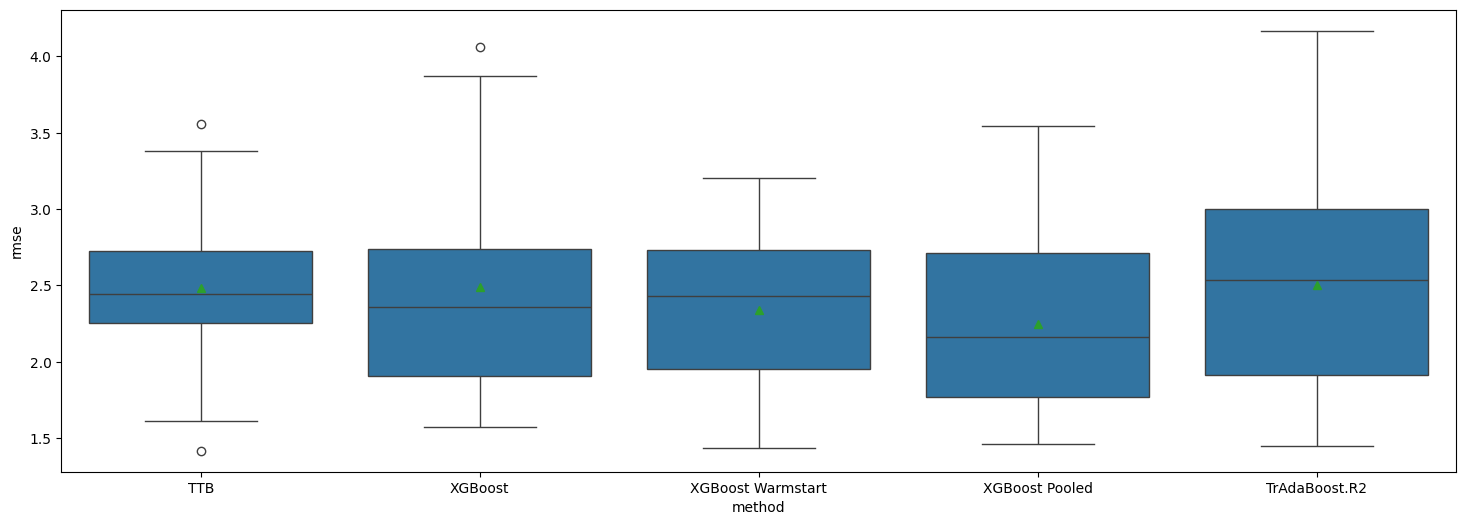

In [23]:
plt.figure(figsize = (18,6))
#Boxplot
dat = pd.read_csv(f'results/ttb_LS_{index}.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
#dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_LSTransferTreeBoost_params = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=nr_of_seeds
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results/xgb_{index}.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, best_XGBoost_params = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost['method'] = 'XGBoost'


data = pd.read_csv(f'results/xgb_warmstart_{index}.csv')
xgboost_data_warmstart = data
xgboost_data_warmstart['method'] = 'XGBoost Warmstart'

best_XGBoost_warmstart, best_XGBoost_params_warmstart = topk_per_d_per_method(
    xgboost_data_warmstart,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost_warmstart['method'] = 'XGBoost Warmstart'

data = pd.read_csv(f'results/xgb_naive_{index}.csv')
xgboost_data_pooled = data
xgboost_data_pooled['method'] = 'XGBoost Pooled'

best_XGBoost_pooled, best_XGBoost_params_pooled = topk_per_d_per_method(
    xgboost_data_pooled,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost_pooled['method'] = 'XGBoost Pooled'

data = pd.read_csv(f'results/trada_{index}.csv')
trada_data = data
trada_data['method'] = 'TrAdaBoost.R2'

best_trada, best_trada_params = topk_per_d_per_method(
    trada_data,
['lr', 'n_estimators', 'tree_size'], k=nr_of_seeds
)
best_trada['method'] = 'TrAdaBoost.R2'



df = best_LSTransferTreeBoost
#df = best_XGBoost
df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
df = pd.concat([df, best_XGBoost_warmstart])
df = pd.concat([df, best_XGBoost_pooled])
df = pd.concat([df, best_trada])

marker_dict = {
'TransferTreeBoost': 'o',
'XGBoost': '^',
}

linestyles_dict = {
    'LSTransferTreeBoost': '-',
    'XGBoost': '--', 
}
    
linestyles_dict=['-', '--']


sns.boxplot(
data=df,
x='method', y='rmse', showmeans = True)





In [24]:
#Get best params in order
best_LSTransferTreeBoost_params.iloc[::nr_of_seeds]

,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,n_seeds,seed,epochs,val_rmse,val_mae,rmse,mae,method
1241,0.2,3.0,1.0,0.0,0.5,2.482267,30,877.0,400.0,2.269598,1.768204,2.240723,1.562213,TransferTreeBoost


In [25]:
#Get best params in order
best_XGBoost_params.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
2218,0.3,1.0,2.489162,30,2226,888.0,2.656142,1.507047,1.868894,1.349664,XGBoost


In [26]:
#Get best params in order
best_XGBoost_params_warmstart.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
67,0.2,1.0,2.337014,30,42,860.0,2.034739,1.55575,2.490122,1.666177,XGBoost Warmstart


In [27]:
#Get best params in order
best_XGBoost_params_pooled.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,n_seeds,Unnamed: 0,seed,subsample,val_rmse,val_mae,rmse,mae,method
1770,0.125,2.0,2.244728,30,1716,882.0,1.0,1.428001,0.997625,2.886988,2.123218,XGBoost Pooled


In [28]:
best_trada_params.iloc[::nr_of_seeds]

,lr,n_estimators,tree_size,avg_rmse,n_seeds,Unnamed: 0,seed,rmse,mae,method
11,0.1,10.0,4.0,2.502728,30,3,860.0,2.138437,1.551076,TrAdaBoost.R2


In [29]:
#Get best params in order
import numpy as np
print(
    np.round(best_LSTransferTreeBoost_params['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_LSTransferTreeBoost_params['rmse']), 3), "&",
    np.round(best_XGBoost_params['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_XGBoost_params['rmse']), 3), "&",
    np.round(best_XGBoost_params_warmstart['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_XGBoost_params_warmstart['rmse']), 3), "&",
    np.round(best_XGBoost_params_pooled['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_XGBoost_params_pooled['rmse']), 3), "&",
    np.round(best_trada_params['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_trada_params['rmse']), 3)
)

2.482 & 0.502 & 2.489 & 0.647 & 2.337 & 0.499 & 2.245 & 0.563 & 2.503 & 0.699


In [30]:
#Print best hyperparameters for TransferTreeBoost
print(float(best_LSTransferTreeBoost_params.iloc[0]['v']), "&",
      float(best_LSTransferTreeBoost_params.iloc[0]['target_tree_size']), "&",
      float(best_LSTransferTreeBoost_params.iloc[0]['source_tree_size']), "&",
      float(best_LSTransferTreeBoost_params.iloc[0]['m_0']), "&",
      float(best_LSTransferTreeBoost_params.iloc[0]['k']))

0.2 & 1.0 & 3.0 & 0.5 & 0.0


In [31]:
data = pd.read_csv(f'results/ResNet_finetuned2_{index}.csv')
MLP_data = data

best_MLP, best_MLP_params = topk_per_d_per_method(
    MLP_data,
['learning_rate', 'dropout', 'd_main', 'num_blocks'], k=nr_of_seeds
)

print(np.round(best_MLP_params['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_MLP_params['rmse']), 3))

3.059 & 0.805


In [32]:
best_MLP_params

,learning_rate,dropout,d_main,num_blocks,avg_rmse,n_seeds,seed,val_rmse,val_mae,rmse,mae
662,0.0005,0.0,256.0,4.0,3.059132,30,887.0,4.258375,2.972362,3.661557,2.559335
711,0.0005,0.0,256.0,4.0,3.059132,30,889.0,3.716521,2.686778,3.303145,2.705614
310,0.0005,0.0,256.0,4.0,3.059132,30,872.0,2.504812,1.900538,4.111084,2.693393
253,0.0005,0.0,256.0,4.0,3.059132,30,870.0,3.303400,2.522654,2.466899,2.072548
62,0.0005,0.0,256.0,4.0,3.059132,30,862.0,1.802091,1.478413,3.230952,2.242013
630,0.0005,0.0,256.0,4.0,3.059132,30,886.0,3.334980,2.603438,3.533630,2.685576
357,0.0005,0.0,256.0,4.0,3.059132,30,874.0,2.533265,1.937637,1.871238,1.375020
589,0.0005,0.0,256.0,4.0,3.059132,30,884.0,2.639549,2.157321,2.430860,1.883454
369,0.0005,0.0,256.0,4.0,3.059132,30,875.0,3.815986,2.968421,3.658041,2.571218
397,0.0005,0.0,256.0,4.0,3.059132,30,876.0,3.488337,2.353341,1.897682,1.463731
